In [1]:
# ======================================
# 03 Model Training + Signal Validation - V4
# ======================================
#
# Purpose:
# --------
# This notebook trains and validates long-horizon stock selection models.
#
# V4 upgrades:
#   1. Uses features_v4.parquet from notebook 02
#   2. Loads feature family definitions from feature_families_v4.json
#   3. Trains separate signal variants:
#        - shared_baseline_v4
#        - core_alpha_v4
#        - convex_alpha_v4
#   4. Exports scored test sets for notebook 04 portfolio backtesting
#
# Notebook 04 then handles portfolio construction, top-k sensitivity,
# contributor concentration, and cohort/stress testing.

from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import joblib

from sklearn.isotonic import IsotonicRegression

# ---- Paths ----
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROJECT_ROOT / "models"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

PRICE_FILE = RAW_DIR / "prices.parquet"
BENCHMARK_PRICE_FILE = RAW_DIR / "benchmark_prices.parquet"

FEATURE_FILE = PROCESSED_DIR / "features_v4.parquet"
FEATURE_FAMILY_FILE = PROCESSED_DIR / "feature_families_v4.json"

# ---- Main V4 output files ----
V4_RESULTS_DIR = PROCESSED_DIR / "v4_model_results"
V4_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_RESULTS_FILE = V4_RESULTS_DIR / "v4_model_signal_summary.csv"
BUCKET_COMPARE_FILE = V4_RESULTS_DIR / "v4_bucket_compare_long.csv"
BUCKET_PIVOT_FILE = V4_RESULTS_DIR / "v4_bucket_actual_means.csv"
QUICK_STRATEGY_FILE = V4_RESULTS_DIR / "v4_quick_strategy_compare.csv"

# ---- Scored test outputs consumed by notebook 04 ----
SCORED_TEST_FILES = {
    "shared_baseline_v4": PROCESSED_DIR / "scored_test_shared_baseline_v4.parquet",
    "core_alpha_v4": PROCESSED_DIR / "scored_test_core_alpha_v4.parquet",
    "convex_alpha_v4": PROCESSED_DIR / "scored_test_convex_alpha_v4.parquet",
}

# ---- Model artifact outputs ----
MODEL_FILES = {
    "shared_baseline_v4": MODEL_DIR / "lightgbm_shared_baseline_v4.joblib",
    "core_alpha_v4": MODEL_DIR / "lightgbm_core_alpha_v4.joblib",
    "convex_alpha_v4": MODEL_DIR / "lightgbm_convex_alpha_v4.joblib",
}

ISO_FILES = {
    "shared_baseline_v4": MODEL_DIR / "isotonic_shared_baseline_v4.joblib",
    "core_alpha_v4": MODEL_DIR / "isotonic_core_alpha_v4.joblib",
    "convex_alpha_v4": MODEL_DIR / "isotonic_convex_alpha_v4.joblib",
}

FEATURE_COLS_FILES = {
    "shared_baseline_v4": MODEL_DIR / "feature_cols_shared_baseline_v4.joblib",
    "core_alpha_v4": MODEL_DIR / "feature_cols_core_alpha_v4.joblib",
    "convex_alpha_v4": MODEL_DIR / "feature_cols_convex_alpha_v4.joblib",
}

print("Project root:", PROJECT_ROOT)
print("Feature file:", FEATURE_FILE)
print("Feature family file:", FEATURE_FAMILY_FILE)

Project root: /Users/neilyejjey/stock_signal_engine_v1
Feature file: /Users/neilyejjey/stock_signal_engine_v1/data/processed/features_v4.parquet
Feature family file: /Users/neilyejjey/stock_signal_engine_v1/data/processed/feature_families_v4.json


In [2]:
# ======================================
# Load Prices + Engineered V4 Features
# ======================================

prices = pd.read_parquet(PRICE_FILE)
features = pd.read_parquet(FEATURE_FILE)

with open(FEATURE_FAMILY_FILE, "r") as f:
    feature_families = json.load(f)

# ---- Date handling ----
prices["date"] = pd.to_datetime(prices["date"])
features["date"] = pd.to_datetime(features["date"])

# ---- Ticker cleanup ----
prices["ticker"] = prices["ticker"].astype(str).str.upper().str.strip()
features["ticker"] = features["ticker"].astype(str).str.upper().str.strip()

# ---- Sorting ----
prices = prices.sort_values(["ticker", "date"]).reset_index(drop=True)
features = features.sort_values(["ticker", "date"]).reset_index(drop=True)

print("Prices shape:", prices.shape)
print("Features shape:", features.shape)

print("\nFeature families:")
for family, cols in feature_families.items():
    print(f"{family}: {len(cols)} features")

print("\nFeature columns:")
print(features.columns.tolist())

features.head()

Prices shape: (1895356, 10)
Features shape: (1903828, 38)

Feature families:
shared: 22 features
size: 0 features
core_alpha: 4 features
convex_alpha: 4 features

Feature columns:
['date', 'ticker', 'ret_6m', 'ret_12m', 'vol_12m', 'drawdown', 'pe_ratio', 'earnings_yield', 'ret_6m_rank', 'ret_12m_rank', 'vol_12m_rank', 'drawdown_rank', 'drawdown_severity_rank', 'low_vol_rank', 'momentum_vol_adj', 'momentum_composite', 'quality_value_combo', 'earnings_yield_rank', 'ey_rank', 'pe_ratio_rank', 'pe_cheap_rank', 'sector_earnings_yield_rank', 'sector_pe_ratio_rank', 'sector_pe_cheap_rank', 'valuation_rank_combo', 'sector_valuation_rank_combo', 'quality_value_combo_ranked', 'sector', 'sub_industry', 'company', 'core_quality_value_combo', 'core_stability_combo', 'core_momentum_quality_combo', 'core_defensive_value_combo', 'convex_momentum_value_combo', 'convex_momentum_vol_combo', 'convex_rebound_combo', 'convex_value_rebound_combo']


,date,ticker,ret_6m,ret_12m,vol_12m,drawdown,pe_ratio,earnings_yield,ret_6m_rank,ret_12m_rank,...,sub_industry,company,core_quality_value_combo,core_stability_combo,core_momentum_quality_combo,core_defensive_value_combo,convex_momentum_value_combo,convex_momentum_vol_combo,convex_rebound_combo,convex_value_rebound_combo
0,2010-01-04,A,NaN,NaN,NaN,0.000000,26.902868,0.037171,0.5,0.5,...,Life Sciences Tools & Services,Agilent Technologies,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.399881
1,2010-01-05,A,NaN,NaN,NaN,-0.010863,26.902868,0.037171,0.5,0.5,...,Life Sciences Tools & Services,Agilent Technologies,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.705482
2,2010-01-06,A,NaN,NaN,NaN,-0.014377,26.902868,0.037171,0.5,0.5,...,Life Sciences Tools & Services,Agilent Technologies,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.686614
3,2010-01-07,A,NaN,NaN,NaN,-0.015655,26.902868,0.037171,0.5,0.5,...,Life Sciences Tools & Services,Agilent Technologies,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.646520
4,2010-01-08,A,NaN,NaN,NaN,-0.015974,26.902868,0.037171,0.5,0.5,...,Life Sciences Tools & Services,Agilent Technologies,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.592274


In [3]:
# ======================================
# Load / Build Benchmark Series
# ======================================
#
# Benchmark:
#   SPY is used as the market benchmark for excess-return labels.
#
# If benchmark_prices.parquet exists from notebook 01, use it.
# Otherwise, fall back to yfinance.

BENCHMARK_TICKER = "SPY"

if BENCHMARK_PRICE_FILE.exists():
    benchmark_prices = pd.read_parquet(BENCHMARK_PRICE_FILE)
    benchmark_prices["date"] = pd.to_datetime(benchmark_prices["date"])
    benchmark_prices["ticker"] = benchmark_prices["ticker"].astype(str).str.upper().str.strip()

    benchmark = (
        benchmark_prices[benchmark_prices["ticker"] == BENCHMARK_TICKER]
        [["date", "adj_close"]]
        .rename(columns={"adj_close": "benchmark_adj_close"})
        .sort_values("date")
        .reset_index(drop=True)
    )

    print(f"Loaded benchmark from: {BENCHMARK_PRICE_FILE}")

else:
    print("Benchmark file not found. Falling back to yfinance download.")

    import yfinance as yf

    START_DATE = prices["date"].min().strftime("%Y-%m-%d")
    END_DATE = (prices["date"].max() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

    benchmark = yf.download(
        BENCHMARK_TICKER,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=False,
        progress=False,
        threads=False,
    )

    benchmark.columns = [
        col[0] if isinstance(col, tuple) else col
        for col in benchmark.columns
    ]

    benchmark = benchmark.reset_index().rename(columns={
        "Date": "date",
        "Adj Close": "benchmark_adj_close",
    })

    benchmark["date"] = pd.to_datetime(benchmark["date"])

    benchmark = benchmark[
        ["date", "benchmark_adj_close"]
    ].sort_values("date").reset_index(drop=True)

print("Benchmark shape:", benchmark.shape)
benchmark.head()

Loaded benchmark from: /Users/neilyejjey/stock_signal_engine_v1/data/raw/benchmark_prices.parquet
Benchmark shape: (4024, 2)


,date,benchmark_adj_close
0,2010-01-04,84.578468
1,2010-01-05,84.802353
2,2010-01-06,84.862068
3,2010-01-07,85.220284
4,2010-01-08,85.503876


In [4]:
# ======================================
# Create Forward 3-Year Stock + Benchmark Returns
# ======================================
#
# FORWARD_DAYS:
#   Approximate number of trading days in 3 years.
#
# For each stock/date:
#   fwd_3y_stock_return = future stock price / current stock price - 1
#
# For benchmark/date:
#   fwd_3y_benchmark_return = future SPY price / current SPY price - 1

FORWARD_DAYS = 252 * 3  # ~3 trading years

# ---- Stock forward returns ----
prices = prices.copy()

prices["fwd_3y_stock_return"] = (
    prices.groupby("ticker")["adj_close"].shift(-FORWARD_DAYS)
    / prices["adj_close"]
    - 1
)

stock_forward_returns = prices[
    ["date", "ticker", "fwd_3y_stock_return"]
].copy()

# ---- Benchmark forward returns ----
benchmark = benchmark.copy()

benchmark["fwd_3y_benchmark_return"] = (
    benchmark["benchmark_adj_close"].shift(-FORWARD_DAYS)
    / benchmark["benchmark_adj_close"]
    - 1
)

benchmark_forward_returns = benchmark[
    ["date", "fwd_3y_benchmark_return"]
].copy()

print("Stock forward returns:", stock_forward_returns.shape)
print("Benchmark forward returns:", benchmark_forward_returns.shape)

stock_forward_returns.head()

Stock forward returns: (1895356, 3)
Benchmark forward returns: (4024, 2)


,date,ticker,fwd_3y_stock_return
0,2010-01-04,A,0.383022
1,2010-01-05,A,0.388097
2,2010-01-06,A,0.381916
3,2010-01-07,A,0.421081
4,2010-01-08,A,0.432036


In [5]:
# ======================================
# Build Forward Excess-Return Labels
# ======================================
#
# This creates the model target:
#
#   excess_fwd_3y_return = stock 3Y return - SPY 3Y return
#
# This makes the model a cross-sectional stock selection engine:
#   "Which stocks are likely to beat SPY over the next ~3 years?"

labels = stock_forward_returns.merge(
    benchmark_forward_returns,
    on="date",
    how="left",
)

labels["excess_fwd_3y_return"] = (
    labels["fwd_3y_stock_return"]
    - labels["fwd_3y_benchmark_return"]
)

# Legacy binary label retained for diagnostics only.
# The model itself uses regression.
labels["label"] = (labels["excess_fwd_3y_return"] > 0.25).astype(int)

print(
    labels[
        [
            "fwd_3y_stock_return",
            "fwd_3y_benchmark_return",
            "excess_fwd_3y_return",
            "label",
        ]
    ].describe()
)

labels.head()

       fwd_3y_stock_return  fwd_3y_benchmark_return  excess_fwd_3y_return  \
count         1.518750e+06             1.518751e+06          1.518750e+06   
mean          6.354978e-01             4.748736e-01          1.606244e-01   
std           1.032257e+00             1.549060e-01          1.016629e+00   
min          -9.622105e-01             1.119544e-02         -1.750726e+00   
25%           1.733791e-01             3.524694e-01         -2.814721e-01   
50%           4.848495e-01             4.479895e-01          1.917271e-02   
75%           8.640697e-01             5.787033e-01          3.800228e-01   
max           1.179765e+02             1.112218e+00          1.171696e+02   

              label  
count  1.895356e+06  
mean   2.597633e-01  
std    4.385048e-01  
min    0.000000e+00  
25%    0.000000e+00  
50%    0.000000e+00  
75%    1.000000e+00  
max    1.000000e+00  


,date,ticker,fwd_3y_stock_return,fwd_3y_benchmark_return,excess_fwd_3y_return,label
0,2010-01-04,A,0.383022,0.374335,0.008687,0
1,2010-01-05,A,0.388097,0.366960,0.021138,0
2,2010-01-06,A,0.381916,0.362068,0.019848,0
3,2010-01-07,A,0.421081,0.359790,0.061290,0
4,2010-01-08,A,0.432036,0.366054,0.065982,0


In [6]:
# ======================================
# Build Modeling Table
# ======================================
#
# Merge engineered features with future labels.
#
# Important:
#   Future returns are only used as training labels.
#   They are not used as input features.

model_df = features.merge(
    labels[
        [
            "date",
            "ticker",
            "fwd_3y_stock_return",
            "fwd_3y_benchmark_return",
            "excess_fwd_3y_return",
            "label",
        ]
    ],
    on=["date", "ticker"],
    how="left",
)

print("Model DF shape:", model_df.shape)
model_df.head()

Model DF shape: (1903828, 42)


,date,ticker,ret_6m,ret_12m,vol_12m,drawdown,pe_ratio,earnings_yield,ret_6m_rank,ret_12m_rank,...,core_momentum_quality_combo,core_defensive_value_combo,convex_momentum_value_combo,convex_momentum_vol_combo,convex_rebound_combo,convex_value_rebound_combo,fwd_3y_stock_return,fwd_3y_benchmark_return,excess_fwd_3y_return,label
0,2010-01-04,A,NaN,NaN,NaN,0.000000,26.902868,0.037171,0.5,0.5,...,1.0,1.0,1.0,1.0,1.0,1.399881,0.383022,0.374335,0.008687,0.0
1,2010-01-05,A,NaN,NaN,NaN,-0.010863,26.902868,0.037171,0.5,0.5,...,1.0,1.0,1.0,1.0,1.0,1.705482,0.388097,0.366960,0.021138,0.0
2,2010-01-06,A,NaN,NaN,NaN,-0.014377,26.902868,0.037171,0.5,0.5,...,1.0,1.0,1.0,1.0,1.0,1.686614,0.381916,0.362068,0.019848,0.0
3,2010-01-07,A,NaN,NaN,NaN,-0.015655,26.902868,0.037171,0.5,0.5,...,1.0,1.0,1.0,1.0,1.0,1.646520,0.421081,0.359790,0.061290,0.0
4,2010-01-08,A,NaN,NaN,NaN,-0.015974,26.902868,0.037171,0.5,0.5,...,1.0,1.0,1.0,1.0,1.0,1.592274,0.432036,0.366054,0.065982,0.0


In [7]:
# ======================================
# Define V4 Feature Sets
# ======================================
#
# V4 uses feature families created in notebook 02:
#
# shared:
#   Common signal foundation used by all models.
#
# core_alpha:
#   Features designed for diversified durable VOO/SPY beaters.
#
# convex_alpha:
#   Features designed for concentrated right-tail / power-law candidates.
#
# Important:
#   Prior ablation showed raw pe_ratio hurt Convex Alpha behavior.
#   Therefore convex_alpha_v4 removes raw pe_ratio while retaining ranked
#   valuation features such as pe_cheap_rank and valuation_rank_combo.

def dedupe_preserve_order(cols):
    seen = set()
    output = []

    for col in cols:
        if col not in seen:
            seen.add(col)
            output.append(col)

    return output


shared_features = feature_families.get("shared", [])
core_features = feature_families.get("core_alpha", [])
convex_features = feature_families.get("convex_alpha", [])

# ---- Convex-specific adjustment ----
# Keep ranked valuation features, but remove raw P/E.
convex_shared_features = [
    c for c in shared_features
    if c != "pe_ratio"
]

FEATURE_SETS = {
    "shared_baseline_v4": dedupe_preserve_order(
        shared_features
    ),

    "core_alpha_v4": dedupe_preserve_order(
        shared_features
        + core_features
    ),

    "convex_alpha_v4": dedupe_preserve_order(
        convex_shared_features
        + convex_features
    ),
}

target_raw_col = "excess_fwd_3y_return"
target_col = "target"

# ---- Validate feature sets ----
for model_name, cols in FEATURE_SETS.items():
    missing = [c for c in cols if c not in model_df.columns]

    print(model_name)
    print("  features:", len(cols))
    print("  missing:", missing)

    if missing:
        raise ValueError(f"{model_name} missing expected feature columns: {missing}")

# Use shared baseline as the single-model baseline in the first half of notebook.
feature_cols = FEATURE_SETS["shared_baseline_v4"]

print("\nBaseline feature columns:")
feature_cols

shared_baseline_v4
  features: 22
  missing: []
core_alpha_v4
  features: 26
  missing: []
convex_alpha_v4
  features: 25
  missing: []

Baseline feature columns:


['ret_6m',
 'ret_12m',
 'vol_12m',
 'drawdown',
 'pe_ratio',
 'earnings_yield',
 'ret_6m_rank',
 'ret_12m_rank',
 'vol_12m_rank',
 'drawdown_rank',
 'drawdown_severity_rank',
 'low_vol_rank',
 'momentum_vol_adj',
 'momentum_composite',
 'quality_value_combo',
 'earnings_yield_rank',
 'pe_cheap_rank',
 'sector_earnings_yield_rank',
 'sector_pe_cheap_rank',
 'valuation_rank_combo',
 'sector_valuation_rank_combo',
 'quality_value_combo_ranked']

In [8]:
# ======================================
# Clean Modeling Table + Transform Target
# ======================================
#
# We train the model on a symmetric log transform of excess returns:
#
#   target = sign(x) * log1p(abs(x))
#
# Why:
#   Long-horizon equity returns are heavy-tailed.
#   The transform reduces outlier dominance while preserving direction.
#
# Important:
#   Because the model predicts this transformed target,
#   predictions must later be inverse-transformed using expm1.

model_df = model_df.replace([np.inf, -np.inf], np.nan)

model_df = model_df.dropna(
    subset=feature_cols + [target_raw_col]
).reset_index(drop=True)

model_df[target_col] = (
    np.sign(model_df[target_raw_col])
    * np.log1p(np.abs(model_df[target_raw_col]))
)

print("Clean model DF shape:", model_df.shape)

print("\nFeature nulls:")
print(model_df[feature_cols].isnull().sum())

print("\nTarget summary:")
print(model_df[[target_raw_col, target_col]].describe())

model_df[feature_cols + ["sector", target_raw_col, target_col]].head()

Clean model DF shape: (1311589, 43)

Feature nulls:
ret_6m                         0
ret_12m                        0
vol_12m                        0
drawdown                       0
pe_ratio                       0
earnings_yield                 0
ret_6m_rank                    0
ret_12m_rank                   0
vol_12m_rank                   0
drawdown_rank                  0
drawdown_severity_rank         0
low_vol_rank                   0
momentum_vol_adj               0
momentum_composite             0
quality_value_combo            0
earnings_yield_rank            0
pe_cheap_rank                  0
sector_earnings_yield_rank     0
sector_pe_cheap_rank           0
valuation_rank_combo           0
sector_valuation_rank_combo    0
quality_value_combo_ranked     0
dtype: int64

Target summary:
       excess_fwd_3y_return        target
count          1.311589e+06  1.311589e+06
mean           1.584890e-01  7.113243e-02
std            1.024179e+00  4.444135e-01
min           -1.628888e

,ret_6m,ret_12m,vol_12m,drawdown,pe_ratio,earnings_yield,ret_6m_rank,ret_12m_rank,vol_12m_rank,drawdown_rank,...,earnings_yield_rank,pe_cheap_rank,sector_earnings_yield_rank,sector_pe_cheap_rank,valuation_rank_combo,sector_valuation_rank_combo,quality_value_combo_ranked,sector,excess_fwd_3y_return,target
0,0.509190,0.338019,0.019335,-0.000955,26.902868,0.037171,0.862150,0.699764,0.638298,0.780600,...,0.443418,0.465854,0.470588,0.489362,0.909272,0.95995,0.805120,Healthcare,-0.148164,-0.138164
1,0.452223,0.340116,0.019331,-0.010258,26.902868,0.037171,0.871495,0.724057,0.636792,0.787529,...,0.443418,0.465854,0.470588,0.489362,0.909272,0.95995,0.806626,Healthcare,-0.125503,-0.118230
2,0.437001,0.341977,0.019330,-0.012405,26.902868,0.037171,0.866822,0.733491,0.636792,0.713626,...,0.443418,0.465854,0.470588,0.489362,0.909272,0.95995,0.806626,Healthcare,-0.091642,-0.087683
3,0.447818,0.346316,0.019329,-0.010497,26.902868,0.037171,0.885514,0.742925,0.641509,0.773672,...,0.443418,0.465854,0.470588,0.489362,0.909272,0.95995,0.801909,Healthcare,-0.097933,-0.093429
4,0.475887,0.351298,0.019330,-0.007157,26.902868,0.037171,0.894860,0.757075,0.641509,0.849885,...,0.443418,0.465854,0.470588,0.489362,0.909272,0.95995,0.801909,Healthcare,-0.097222,-0.092781


In [9]:
# ======================================
# Downsample to Monthly Observations
# ======================================
#
# Why:
#   Daily rows with 3-year forward labels heavily overlap.
#   That creates high autocorrelation and can make performance look cleaner
#   than it really is.
#
# Approach:
#   For each ticker/month, keep the final available trading day.
#
# This preserves the long-horizon thesis while reducing duplicate signal windows.

model_df["year_month"] = model_df["date"].dt.to_period("M")

model_df_monthly = (
    model_df.sort_values("date")
    .groupby(["ticker", "year_month"])
    .tail(1)
    .reset_index(drop=True)
)

print("Daily shape:  ", model_df.shape)
print("Monthly shape:", model_df_monthly.shape)

model_df_monthly.head()

Daily shape:   (1311589, 44)
Monthly shape: (62653, 44)


,date,ticker,ret_6m,ret_12m,vol_12m,drawdown,pe_ratio,earnings_yield,ret_6m_rank,ret_12m_rank,...,convex_momentum_value_combo,convex_momentum_vol_combo,convex_rebound_combo,convex_value_rebound_combo,fwd_3y_stock_return,fwd_3y_benchmark_return,excess_fwd_3y_return,label,target,year_month
0,2011-01-31,STLD,0.248078,0.153630,0.022015,-0.081210,25.071340,0.039886,0.706294,0.316038,...,1.359152,1.106132,1.440705,1.777525,-0.050810,0.441076,-0.491886,0.0,-0.400041,2011-01
1,2011-01-31,ICE,0.109075,0.230369,0.019112,-0.050812,27.944542,0.035785,0.354312,0.433962,...,1.286252,1.082547,0.943227,1.441204,0.693559,0.441076,0.252483,1.0,0.225128,2011-01
2,2011-01-31,GOOGL,0.224200,0.126337,0.017163,-0.061395,31.637035,0.031609,0.657343,0.257075,...,0.919425,0.747642,1.306303,1.311311,0.887918,0.441076,0.446842,1.0,0.369383,2011-01
3,2011-01-31,AMZN,0.412843,0.427105,0.020753,-0.112993,34.945606,0.028616,0.920746,0.735849,...,1.241499,1.488208,1.749845,1.334749,1.040498,0.441076,0.599421,1.0,0.469642,2011-01
4,2011-01-31,SNPS,0.211702,0.270131,0.012511,-0.012737,68.953990,0.014502,0.610723,0.504717,...,0.644733,0.681604,0.802409,0.331702,0.415407,0.441076,-0.025669,0.0,-0.025345,2011-01


In [10]:
# ======================================
# Time-Based Train / Validation / Test Split
# ======================================
#
# Train:
#   Used to fit LightGBM.
#
# Validation:
#   Used for early stopping and isotonic calibration.
#
# Test:
#   Blind out-of-sample evaluation.
#
# Important:
#   The isotonic calibrator is fit only on validation data.
#   Test data is never used to fit either the model or calibrator.

train_end = pd.Timestamp("2017-12-31")
valid_end = pd.Timestamp("2020-12-31")

df = model_df_monthly.copy()

train_df = df[df["date"] <= train_end].copy()
valid_df = df[(df["date"] > train_end) & (df["date"] <= valid_end)].copy()
test_df = df[df["date"] > valid_end].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_valid = valid_df[feature_cols]
y_valid = valid_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test :", X_test.shape, y_test.shape)

print("\nDate ranges:")
print("Train:", train_df["date"].min(), "to", train_df["date"].max())
print("Valid:", valid_df["date"].min(), "to", valid_df["date"].max())
print("Test :", test_df["date"].min(), "to", test_df["date"].max())

Train: (35531, 22) (35531,)
Valid: (16129, 22) (16129,)
Test : (10993, 22) (10993,)

Date ranges:
Train: 2011-01-31 00:00:00 to 2017-12-29 00:00:00
Valid: 2018-01-31 00:00:00 to 2020-12-31 00:00:00
Test : 2021-01-29 00:00:00 to 2022-12-23 00:00:00


In [11]:
# ======================================
# Train LightGBM Regressor
# ======================================
#
# Objective:
#   Predict transformed 3-year excess return.
#
# Notes:
#   - Early stopping uses validation set.
#   - The model is optimized for signal generation/ranking, not direct trading.
#   - Calibration happens after training.

model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="l2",
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(50),
    ],
)

model

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001190 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5598
[LightGBM] [Info] Number of data points in the train set: 35531, number of used features: 22
[LightGBM] [Info] Start training from score 0.104877
Training until validation scores don't improve for 50 rounds
[50]	valid_0's l2: 0.190647
[100]	valid_0's l2: 0.191351
Early stopping, best iteration is:
[57]	valid_0's l2: 0.189779


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, min_child_samples=100,
              n_estimators=500, objective='regression', random_state=42,
              reg_alpha=1.0, reg_lambda=1.0, subsample=0.8)

In [12]:
# ======================================
# Score Validation + Test Sets
# ======================================
#
# The model predicts transformed target values.
#
# We convert predictions back to raw return space using:
#
#   raw_pred = sign(pred) * expm1(abs(pred))
#
# This is the inverse of the symmetric log target transform.

def inverse_symmetric_log(x):
    return np.sign(x) * np.expm1(np.abs(x))


valid_df = valid_df.copy()
test_df = test_df.copy()

# ---- Raw model predictions in transformed target space ----
valid_preds = model.predict(X_valid)
test_preds = model.predict(X_test)

valid_df["predicted_target"] = valid_preds
test_df["predicted_target"] = test_preds

# ---- Convert back to raw return space ----
valid_df["predicted_excess_return"] = inverse_symmetric_log(valid_preds)
test_df["predicted_excess_return"] = inverse_symmetric_log(test_preds)

print("Raw validation correlation:")
print(valid_df["predicted_excess_return"].corr(valid_df[target_raw_col]))

print("\nRaw test correlation:")
print(test_df["predicted_excess_return"].corr(test_df[target_raw_col]))

test_df[
    ["date", "ticker", target_raw_col, "predicted_target", "predicted_excess_return"]
].head()

Raw validation correlation:
0.36196051681142377

Raw test correlation:
0.20563433547327462


,date,ticker,excess_fwd_3y_return,predicted_target,predicted_excess_return
51660,2021-01-29,STE,-0.154315,0.133080,0.142341
51661,2021-01-29,AOS,0.162880,0.072603,0.075304
51662,2021-01-29,SPG,0.389615,0.192986,0.212866
51663,2021-01-29,PTC,-0.032168,0.226734,0.254496
51664,2021-01-29,LRCX,0.399519,0.307761,0.360376


In [13]:
# ======================================
# Fit Isotonic Calibration on Validation Set
# ======================================
#
# Why:
#   Tree models can be good rankers but poor magnitude estimators.
#   Isotonic Regression learns a monotonic mapping from predicted values
#   to realized excess returns.
#
# Critical anti-leakage rule:
#   Fit isotonic regression on validation data only.
#   Apply it to test data afterward.

iso = IsotonicRegression(out_of_bounds="clip")

iso.fit(
    valid_df["predicted_excess_return"],
    valid_df[target_raw_col],
)

valid_df["calibrated_pred"] = iso.transform(
    valid_df["predicted_excess_return"]
)

test_df["calibrated_pred"] = iso.transform(
    test_df["predicted_excess_return"]
)

print("Validation correlations:")
print("Raw:       ", valid_df["predicted_excess_return"].corr(valid_df[target_raw_col]))
print("Calibrated:", valid_df["calibrated_pred"].corr(valid_df[target_raw_col]))

print("\nTest correlations:")
print("Raw:       ", test_df["predicted_excess_return"].corr(test_df[target_raw_col]))
print("Calibrated:", test_df["calibrated_pred"].corr(test_df[target_raw_col]))

test_df[
    ["date", "ticker", target_raw_col, "predicted_excess_return", "calibrated_pred"]
].head()

Validation correlations:
Raw:        0.36196051681142377
Calibrated: 0.4144964379047088

Test correlations:
Raw:        0.20563433547327462
Calibrated: 0.20834584319412355


,date,ticker,excess_fwd_3y_return,predicted_excess_return,calibrated_pred
51660,2021-01-29,STE,-0.154315,0.142341,0.058886
51661,2021-01-29,AOS,0.162880,0.075304,-0.057695
51662,2021-01-29,SPG,0.389615,0.212866,0.286596
51663,2021-01-29,PTC,-0.032168,0.254496,0.286596
51664,2021-01-29,LRCX,0.399519,0.360376,0.401088


In [14]:
# ======================================
# Prediction Diagnostics
# ======================================
#
# delta:
#   calibrated prediction - realized excess return
#
# Positive delta:
#   Model overpredicted.
#
# Negative delta:
#   Model underpredicted.
#
# This is mainly diagnostic; portfolio construction uses rankings.

test_df["delta"] = test_df["calibrated_pred"] - test_df[target_raw_col]

print("Prediction error summary:")
print(test_df["delta"].describe())

print("\nPrediction summaries:")
print(
    test_df[
        ["predicted_excess_return", "calibrated_pred", target_raw_col]
    ].describe()
)

Prediction error summary:
count    10993.000000
mean         0.021728
std          1.882911
min       -100.926689
25%         -0.203770
50%          0.201528
75%          0.533424
max          3.958352
Name: delta, dtype: float64

Prediction summaries:
       predicted_excess_return  calibrated_pred  excess_fwd_3y_return
count             10993.000000     10993.000000          10993.000000
mean                  0.143399         0.141556              0.119828
std                   0.136897         0.413128              1.925119
min                  -0.248047        -0.590583             -1.524819
25%                   0.054256        -0.057695             -0.442574
50%                   0.111585         0.058886             -0.139682
75%                   0.197864         0.286596              0.263826
max                   0.957601         5.412476            102.349818


In [15]:
# ======================================
# Bucket Signal Validation
# ======================================
#
# We rank test predictions and split them into quintiles.
#
# This asks:
#   Do higher predicted buckets actually produce higher realized excess returns?
#
# This is signal validation, not portfolio backtesting.
# Notebook 04 handles portfolio strategy analysis.

test_df["pred_rank"] = test_df["calibrated_pred"].rank(method="first")

test_df["pred_bucket"] = pd.qcut(
    test_df["pred_rank"],
    q=5,
    labels=False,
)

bucket_stats = test_df.groupby("pred_bucket").agg({
    "calibrated_pred": "mean",
    target_raw_col: "mean",
    "delta": ["mean", "std", "count"],
})

bucket_stats.columns = [
    "pred_mean",
    "actual_mean",
    "delta_mean",
    "delta_std",
    "count",
]

bucket_stats = bucket_stats.sort_index()

bucket_stats

,pred_mean,actual_mean,delta_mean,delta_std,count
pred_bucket,,,,,
0,-0.147206,-0.141101,-0.006106,0.489591,2199
1,-0.050997,-0.116044,0.065047,0.648555,2198
2,0.058876,0.028815,0.030062,0.699386,2199
3,0.182274,0.131756,0.050518,1.363857,2198
4,0.664764,0.695615,-0.030850,3.836032,2199


In [16]:
# ======================================
# Signal Strength Metrics
# ======================================
#
# Top-bottom spread:
#   Difference between realized excess return in top and bottom prediction buckets.
#
# Top bucket positive rate:
#   Share of top-bucket stocks that beat SPY over the 3-year horizon.

spread = (
    bucket_stats["actual_mean"].iloc[-1]
    - bucket_stats["actual_mean"].iloc[0]
)

top_bucket = test_df[test_df["pred_bucket"] == test_df["pred_bucket"].max()]
hit_rate_top = (top_bucket[target_raw_col] > 0).mean()

is_monotonic = bucket_stats["actual_mean"].is_monotonic_increasing

signal_summary = pd.DataFrame([
    {
        "top_bottom_spread": spread,
        "top_bucket_positive_rate": hit_rate_top,
        "bucket_actuals_monotonic": is_monotonic,
        "raw_test_corr": test_df["predicted_excess_return"].corr(test_df[target_raw_col]),
        "calibrated_test_corr": test_df["calibrated_pred"].corr(test_df[target_raw_col]),
    }
])

print("Top-Bottom Spread:", spread)
print("Top Bucket Positive Rate:", hit_rate_top)
print("Actual bucket means monotonic:", is_monotonic)

signal_summary

Top-Bottom Spread: 0.836715426534234
Top Bucket Positive Rate: 0.4779445202364711
Actual bucket means monotonic: True


,top_bottom_spread,top_bucket_positive_rate,bucket_actuals_monotonic,raw_test_corr,calibrated_test_corr
0,0.836715,0.477945,True,0.205634,0.208346


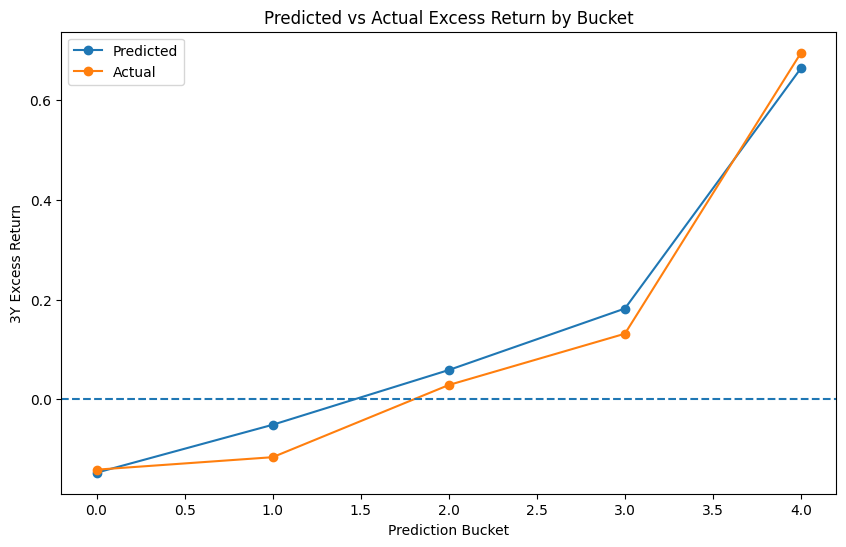

In [17]:
# ======================================
# Bucket Plot: Predicted vs Actual
# ======================================
#
# Visual check:
#   The actual line should generally increase across prediction buckets.
#
# If actual returns are monotonic across buckets,
# the model is ranking stocks in a useful direction.

plt.figure(figsize=(10, 6))

plt.plot(
    bucket_stats.index,
    bucket_stats["pred_mean"],
    marker="o",
    label="Predicted",
)

plt.plot(
    bucket_stats.index,
    bucket_stats["actual_mean"],
    marker="o",
    label="Actual",
)

plt.axhline(0, linestyle="--")
plt.xlabel("Prediction Bucket")
plt.ylabel("3Y Excess Return")
plt.title("Predicted vs Actual Excess Return by Bucket")
plt.legend()
plt.show()

In [18]:
# ======================================
# Feature Importance
# ======================================
#
# LightGBM feature importance is used as a sanity check:
#
#   - Is the model relying on sensible features?
#   - Is one engineered feature dominating too heavily?
#
# This is not a complete interpretability analysis.
# Future work can add permutation importance or SHAP.

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_,
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False,
).reset_index(drop=True)

feature_importance

,feature,importance
0,sector_earnings_yield_rank,332
1,pe_ratio,276
2,sector_pe_cheap_rank,256
3,sector_valuation_rank_combo,156
4,quality_value_combo,85
5,earnings_yield_rank,83
6,pe_cheap_rank,82
7,vol_12m,80
8,earnings_yield,69
9,valuation_rank_combo,54


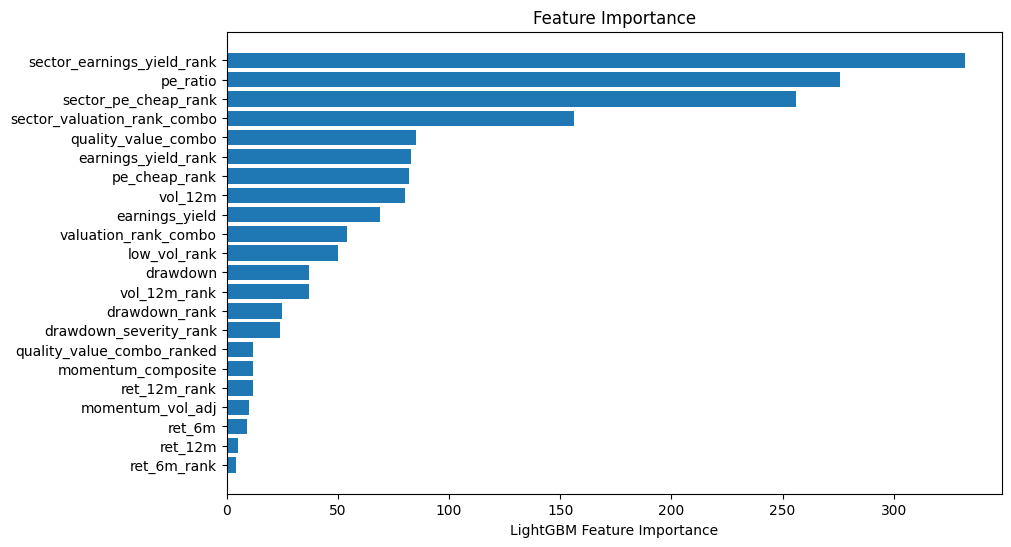

In [19]:
# ======================================
# Feature Importance Plot
# ======================================

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"][::-1],
    feature_importance["importance"][::-1],
)

plt.xlabel("LightGBM Feature Importance")
plt.title("Feature Importance")
plt.show()

In [20]:
# ======================================
# Optional Quick Top-K Sanity Check
# ======================================
#
# This is not the official strategy backtest.
# It is only a lightweight sanity check before exporting scored signals.
#
# Official portfolio/cohort analysis lives in notebook 04.

def quick_topk_summary(df, top_k=20, score_col="calibrated_pred"):
    portfolio = []

    for date, group in df.groupby("date"):
        group = group.dropna(subset=[score_col]).copy()

        if group.empty:
            continue

        subset = group.nlargest(min(top_k, len(group)), score_col).copy()

        ranks = subset[score_col].rank(method="first")
        weights = ranks / ranks.sum()

        subset["weight"] = weights
        portfolio.append(subset)

    portfolio = pd.concat(portfolio, ignore_index=True)

    cohort_returns = (
        portfolio
        .assign(weighted_excess=portfolio[target_raw_col] * portfolio["weight"])
        .groupby("date")
        .agg(
            excess_return=("weighted_excess", "sum"),
            benchmark_return=("fwd_3y_benchmark_return", "first"),
            num_positions=("ticker", "count"),
        )
        .reset_index()
    )

    return {
        "top_k": top_k,
        "mean_excess_return": cohort_returns["excess_return"].mean(),
        "median_excess_return": cohort_returns["excess_return"].median(),
        "excess_std": cohort_returns["excess_return"].std(),
        "hit_rate": (cohort_returns["excess_return"] > 0).mean(),
    }


quick_summary = pd.DataFrame([
    quick_topk_summary(test_df, top_k=3),
    quick_topk_summary(test_df, top_k=5),
    quick_topk_summary(test_df, top_k=20),
])

quick_summary

,top_k,mean_excess_return,median_excess_return,excess_std,hit_rate
0,3,1.264281,0.366242,2.363353,0.52
1,5,1.003111,0.412816,1.395128,0.68
2,20,1.242951,0.719116,1.434331,0.96


In [21]:
# ======================================
# Export Shared Baseline V4 Scored Test Set
# ======================================

BASELINE_MODEL_NAME = "shared_baseline_v4"

export_cols = [
    "date",
    "year_month",
    "ticker",
    "sector",

    # Optional metadata
    "company",
    "sub_industry",

    # Model outputs
    "predicted_target",
    "predicted_excess_return",
    "calibrated_pred",
    "pred_rank",
    "pred_bucket",

    # Actual forward labels
    "fwd_3y_stock_return",
    "fwd_3y_benchmark_return",
    "excess_fwd_3y_return",
    "target",

    # Diagnostics
    "delta",
]

export_cols = [c for c in export_cols if c in test_df.columns]

scored_test = test_df[export_cols].copy()

output_file = SCORED_TEST_FILES[BASELINE_MODEL_NAME]
scored_test.to_parquet(output_file, index=False)

print(f"Saved {BASELINE_MODEL_NAME} scored test set to: {output_file}")
print("Shape:", scored_test.shape)

scored_test.head()

Saved shared_baseline_v4 scored test set to: /Users/neilyejjey/stock_signal_engine_v1/data/processed/scored_test_shared_baseline_v4.parquet
Shape: (10993, 16)


,date,year_month,ticker,sector,company,sub_industry,predicted_target,predicted_excess_return,calibrated_pred,pred_rank,pred_bucket,fwd_3y_stock_return,fwd_3y_benchmark_return,excess_fwd_3y_return,target,delta
51660,2021-01-29,2021-01,STE,Healthcare,Steris,Health Care Equipment,0.133080,0.142341,0.058886,4407.0,2,0.227638,0.381954,-0.154315,-0.143507,0.213201
51661,2021-01-29,2021-01,AOS,Industrials,A. O. Smith,Building Products,0.072603,0.075304,-0.057695,2597.0,1,0.544834,0.381954,0.162880,0.150900,-0.220574
51662,2021-01-29,2021-01,SPG,Real Estate,Simon Property Group,Retail REITs,0.192986,0.212866,0.286596,8139.0,3,0.771569,0.381954,0.389615,0.329027,-0.103019
51663,2021-01-29,2021-01,PTC,Technology,PTC Inc.,Application Software,0.226734,0.254496,0.286596,8140.0,3,0.349785,0.381954,-0.032168,-0.031662,0.318764
51664,2021-01-29,2021-01,LRCX,Technology,Lam Research,Semiconductor Materials & Equipment,0.307761,0.360376,0.401088,9773.0,4,0.781473,0.381954,0.399519,0.336128,0.001570


In [22]:
# ======================================
# Export Shared Baseline V4 Signal Validation Tables
# ======================================

baseline_bucket_stats_file = V4_RESULTS_DIR / "shared_baseline_v4_bucket_stats.csv"
baseline_signal_summary_file = V4_RESULTS_DIR / "shared_baseline_v4_signal_summary.csv"

bucket_stats.to_csv(baseline_bucket_stats_file)
signal_summary.to_csv(baseline_signal_summary_file, index=False)

print(f"Saved bucket stats to:   {baseline_bucket_stats_file}")
print(f"Saved signal summary to: {baseline_signal_summary_file}")

Saved bucket stats to:   /Users/neilyejjey/stock_signal_engine_v1/data/processed/v4_model_results/shared_baseline_v4_bucket_stats.csv
Saved signal summary to: /Users/neilyejjey/stock_signal_engine_v1/data/processed/v4_model_results/shared_baseline_v4_signal_summary.csv


In [23]:
# ======================================
# Save Shared Baseline V4 Model Artifacts
# ======================================

joblib.dump(model, MODEL_FILES[BASELINE_MODEL_NAME])
joblib.dump(iso, ISO_FILES[BASELINE_MODEL_NAME])
joblib.dump(feature_cols, FEATURE_COLS_FILES[BASELINE_MODEL_NAME])

print(f"Saved model to:             {MODEL_FILES[BASELINE_MODEL_NAME]}")
print(f"Saved isotonic calibrator to:{ISO_FILES[BASELINE_MODEL_NAME]}")
print(f"Saved feature columns to:    {FEATURE_COLS_FILES[BASELINE_MODEL_NAME]}")

Saved model to:             /Users/neilyejjey/stock_signal_engine_v1/models/lightgbm_shared_baseline_v4.joblib
Saved isotonic calibrator to:/Users/neilyejjey/stock_signal_engine_v1/models/isotonic_shared_baseline_v4.joblib
Saved feature columns to:    /Users/neilyejjey/stock_signal_engine_v1/models/feature_cols_shared_baseline_v4.joblib


In [24]:
# ======================================
# Define V4 Model Variants
# ======================================
#
# These are not experimental valuation ablations anymore.
# They are intentional signal variants from the V4 feature architecture.

model_variant_df = model_df_monthly.copy()

MODEL_VARIANTS = FEATURE_SETS.copy()

for name, cols in MODEL_VARIANTS.items():
    missing = [c for c in cols if c not in model_variant_df.columns]
    print(name, "features:", len(cols), "| missing:", missing)

    if missing:
        raise ValueError(f"{name} missing expected feature columns: {missing}")

shared_baseline_v4 features: 22 | missing: []
core_alpha_v4 features: 26 | missing: []
convex_alpha_v4 features: 25 | missing: []


In [25]:
# ======================================
# V4 Model Variant Helper Functions
# ======================================
#
# Each V4 model variant uses:
#   - Same train / validation / test split
#   - Same LightGBM parameters
#   - Same symmetric log target
#   - Same validation-only isotonic calibration
#
# This keeps the comparison fair.

def inverse_symmetric_log(x):
    return np.sign(x) * np.expm1(np.abs(x))


def train_score_model_variant(df, feature_cols_variant, model_name):
    # ---- Time split ----
    train_df = df[df["date"] <= train_end].copy()
    valid_df = df[(df["date"] > train_end) & (df["date"] <= valid_end)].copy()
    test_df = df[df["date"] > valid_end].copy()

    # ---- Drop rows with missing features ----
    train_df = train_df.dropna(subset=feature_cols_variant + [target_col, target_raw_col]).copy()
    valid_df = valid_df.dropna(subset=feature_cols_variant + [target_col, target_raw_col]).copy()
    test_df = test_df.dropna(subset=feature_cols_variant + [target_col, target_raw_col]).copy()

    X_train = train_df[feature_cols_variant]
    y_train = train_df[target_col]

    X_valid = valid_df[feature_cols_variant]
    y_valid = valid_df[target_col]

    X_test = test_df[feature_cols_variant]

    # ---- Train model ----
    model_variant = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=100,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=1.0,
        random_state=42,
    )

    model_variant.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="l2",
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(0),
        ],
    )

    # ---- Score validation/test ----
    valid_preds = model_variant.predict(X_valid)
    test_preds = model_variant.predict(X_test)

    valid_df["predicted_target"] = valid_preds
    test_df["predicted_target"] = test_preds

    valid_df["predicted_excess_return"] = inverse_symmetric_log(valid_preds)
    test_df["predicted_excess_return"] = inverse_symmetric_log(test_preds)

    # ---- Validation-only isotonic calibration ----
    iso_variant = IsotonicRegression(out_of_bounds="clip")

    iso_variant.fit(
        valid_df["predicted_excess_return"],
        valid_df[target_raw_col],
    )

    valid_df["calibrated_pred"] = iso_variant.transform(
        valid_df["predicted_excess_return"]
    )

    test_df["calibrated_pred"] = iso_variant.transform(
        test_df["predicted_excess_return"]
    )

    # ---- Prediction diagnostics ----
    test_df["delta"] = test_df["calibrated_pred"] - test_df[target_raw_col]

    # ---- Bucket validation ----
    test_df["pred_rank"] = test_df["calibrated_pred"].rank(method="first")

    test_df["pred_bucket"] = pd.qcut(
        test_df["pred_rank"],
        q=5,
        labels=False,
    )

    bucket_stats = test_df.groupby("pred_bucket").agg({
        "calibrated_pred": "mean",
        target_raw_col: "mean",
        "delta": ["mean", "std", "count"],
    })

    bucket_stats.columns = [
        "pred_mean",
        "actual_mean",
        "delta_mean",
        "delta_std",
        "count",
    ]

    bucket_stats = bucket_stats.sort_index()

    # ---- Signal metrics ----
    spread = (
        bucket_stats["actual_mean"].iloc[-1]
        - bucket_stats["actual_mean"].iloc[0]
    )

    top_bucket = test_df[test_df["pred_bucket"] == test_df["pred_bucket"].max()]
    top_bucket_positive_rate = (top_bucket[target_raw_col] > 0).mean()

    raw_corr = test_df["predicted_excess_return"].corr(test_df[target_raw_col])
    calibrated_corr = test_df["calibrated_pred"].corr(test_df[target_raw_col])

    is_monotonic = bucket_stats["actual_mean"].is_monotonic_increasing

    summary = {
        "model_name": model_name,
        "num_features": len(feature_cols_variant),
        "train_rows": len(train_df),
        "valid_rows": len(valid_df),
        "test_rows": len(test_df),
        "best_iteration": model_variant.best_iteration_,
        "raw_test_corr": raw_corr,
        "calibrated_test_corr": calibrated_corr,
        "top_bottom_spread": spread,
        "top_bucket_actual_mean": bucket_stats["actual_mean"].iloc[-1],
        "bottom_bucket_actual_mean": bucket_stats["actual_mean"].iloc[0],
        "top_bucket_positive_rate": top_bucket_positive_rate,
        "bucket_actuals_monotonic": is_monotonic,
    }

    return {
        "model_name": model_name,
        "model": model_variant,
        "iso": iso_variant,
        "feature_cols": feature_cols_variant,
        "test_df": test_df,
        "bucket_stats": bucket_stats,
        "summary": summary,
    }

In [26]:
# ======================================
# Run V4 Model Variants
# ======================================

model_variant_results = {}

for name, cols in MODEL_VARIANTS.items():
    print(f"\nTraining V4 model variant: {name}")
    print("-" * 60)

    result = train_score_model_variant(
        model_variant_df,
        feature_cols_variant=cols,
        model_name=name,
    )

    model_variant_results[name] = result

print("\nFinished all V4 model variants.")


Training V4 model variant: shared_baseline_v4
------------------------------------------------------------
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001003 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5598
[LightGBM] [Info] Number of data points in the train set: 35531, number of used features: 22
[LightGBM] [Info] Start training from score 0.104877

Training V4 model variant: core_alpha_v4
------------------------------------------------------------
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001403 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6618
[LightGBM] [Info] Number of data points in the train set: 35531, number of used features: 26
[LightGBM] [Info] Start training from score 0.104877

Training V4 model variant: convex_alpha_v4
------------------------------------------------------------


In [27]:
# ======================================
# Compare V4 Signal Metrics
# ======================================

model_variant_summary = pd.DataFrame([
    result["summary"]
    for result in model_variant_results.values()
])

model_variant_summary = model_variant_summary.sort_values(
    "top_bottom_spread",
    ascending=False,
).reset_index(drop=True)

model_variant_summary

,model_name,num_features,train_rows,valid_rows,test_rows,best_iteration,raw_test_corr,calibrated_test_corr,top_bottom_spread,top_bucket_actual_mean,bottom_bucket_actual_mean,top_bucket_positive_rate,bucket_actuals_monotonic
0,shared_baseline_v4,22,35531,16129,10993,57,0.205634,0.208346,0.836715,0.695615,-0.141101,0.477945,True
1,convex_alpha_v4,25,35531,16129,10993,50,0.185766,0.163004,0.793367,0.689349,-0.104018,0.472033,False
2,core_alpha_v4,26,35531,16129,10993,54,0.200622,0.214990,0.738200,0.687904,-0.050296,0.479764,False


In [28]:
# ======================================
# Compare Bucket Actual Means Across V4 Models
# ======================================

bucket_compare = []

for name, result in model_variant_results.items():
    bs = result["bucket_stats"].copy()
    bs["model_name"] = name
    bs = bs.reset_index()

    bucket_compare.append(
        bs[["model_name", "pred_bucket", "pred_mean", "actual_mean", "count"]]
    )

bucket_compare = pd.concat(bucket_compare, ignore_index=True)

bucket_pivot = bucket_compare.pivot(
    index="pred_bucket",
    columns="model_name",
    values="actual_mean",
)

bucket_pivot

model_name,convex_alpha_v4,core_alpha_v4,shared_baseline_v4
pred_bucket,,,
0,-0.104018,-0.050296,-0.141101
1,-0.134622,-0.166216,-0.116044
2,-0.003100,-0.018162,0.028815
3,0.151431,0.145795,0.131756
4,0.689349,0.687904,0.695615


In [29]:
# ======================================
# Quick Core / Convex 3Y Strategy Comparison
# ======================================
#
# This is a lightweight strategy sanity check using the existing 3Y labels.
#
# Official horizon backtest still lives in notebook 04.
#
# Core Alpha:
#   top 20 stocks per month
#
# Convex Alpha:
#   top 3 stocks per month

def quick_strategy_summary(test_df, top_k, power, strategy_name):
    portfolios = []

    for date, group in test_df.groupby("date"):
        group = group.dropna(subset=["calibrated_pred"]).copy()

        if group.empty:
            continue

        subset = group.nlargest(min(top_k, len(group)), "calibrated_pred").copy()

        ranks = subset["calibrated_pred"].rank(method="first")
        weights = ranks ** power
        subset["weight"] = weights / weights.sum()

        portfolios.append(subset)

    portfolio = pd.concat(portfolios, ignore_index=True)

    cohort_returns = (
        portfolio
        .assign(weighted_excess=portfolio[target_raw_col] * portfolio["weight"])
        .groupby("date")
        .agg(
            excess_return=("weighted_excess", "sum"),
            benchmark_return=("fwd_3y_benchmark_return", "first"),
            num_positions=("ticker", "count"),
        )
        .reset_index()
    )

    return {
        "strategy": strategy_name,
        "mean_excess_return": cohort_returns["excess_return"].mean(),
        "median_excess_return": cohort_returns["excess_return"].median(),
        "excess_std": cohort_returns["excess_return"].std(),
        "hit_rate": (cohort_returns["excess_return"] > 0).mean(),
    }


quick_strategy_rows = []

for name, result in model_variant_results.items():
    test_variant = result["test_df"]

    core_summary = quick_strategy_summary(
        test_variant,
        top_k=20,
        power=0.6,
        strategy_name=f"{name}_core_alpha",
    )

    convex_summary = quick_strategy_summary(
        test_variant,
        top_k=3,
        power=0.8,
        strategy_name=f"{name}_convex_alpha",
    )

    quick_strategy_rows.append(core_summary)
    quick_strategy_rows.append(convex_summary)

quick_strategy_compare = pd.DataFrame(quick_strategy_rows)

quick_strategy_compare = quick_strategy_compare.sort_values(
    ["strategy"]
).reset_index(drop=True)

quick_strategy_compare

,strategy,mean_excess_return,median_excess_return,excess_std,hit_rate
0,convex_alpha_v4_convex_alpha,0.841391,0.873161,0.895794,0.84
1,convex_alpha_v4_core_alpha,1.131242,0.715101,1.002435,0.96
2,core_alpha_v4_convex_alpha,1.083935,0.214566,1.889594,0.64
3,core_alpha_v4_core_alpha,1.439492,0.646374,1.466973,0.96
4,shared_baseline_v4_convex_alpha,1.262195,0.372709,2.345226,0.52
5,shared_baseline_v4_core_alpha,1.315423,0.696303,1.629839,0.96


In [30]:
# ======================================
# Save V4 Model Comparison Outputs
# ======================================

model_variant_summary.to_csv(
    MODEL_RESULTS_FILE,
    index=False,
)

bucket_compare.to_csv(
    BUCKET_COMPARE_FILE,
    index=False,
)

bucket_pivot.to_csv(
    BUCKET_PIVOT_FILE,
)

quick_strategy_compare.to_csv(
    QUICK_STRATEGY_FILE,
    index=False,
)

print("Saved V4 model comparison outputs to:", V4_RESULTS_DIR)

Saved V4 model comparison outputs to: /Users/neilyejjey/stock_signal_engine_v1/data/processed/v4_model_results


In [31]:
# ======================================
# Export V4 Scored Test Sets for Notebook 04
# ======================================

export_cols = [
    "date",
    "year_month",
    "ticker",
    "sector",
    "company",
    "sub_industry",
    "predicted_target",
    "predicted_excess_return",
    "calibrated_pred",
    "pred_rank",
    "pred_bucket",
    "fwd_3y_stock_return",
    "fwd_3y_benchmark_return",
    "excess_fwd_3y_return",
    "target",
    "delta",
]

for model_name, output_file in SCORED_TEST_FILES.items():
    result = model_variant_results[model_name]

    test_variant = result["test_df"].copy()
    cols = [c for c in export_cols if c in test_variant.columns]

    test_variant[cols].to_parquet(output_file, index=False)

    print(f"Saved {model_name} scored test set to: {output_file}")
    print("Shape:", test_variant[cols].shape)
    print()

Saved shared_baseline_v4 scored test set to: /Users/neilyejjey/stock_signal_engine_v1/data/processed/scored_test_shared_baseline_v4.parquet
Shape: (10993, 16)

Saved core_alpha_v4 scored test set to: /Users/neilyejjey/stock_signal_engine_v1/data/processed/scored_test_core_alpha_v4.parquet
Shape: (10993, 16)

Saved convex_alpha_v4 scored test set to: /Users/neilyejjey/stock_signal_engine_v1/data/processed/scored_test_convex_alpha_v4.parquet
Shape: (10993, 16)



In [32]:
# ======================================
# Save V4 Model Artifacts
# ======================================

for model_name, result in model_variant_results.items():
    joblib.dump(result["model"], MODEL_FILES[model_name])
    joblib.dump(result["iso"], ISO_FILES[model_name])
    joblib.dump(result["feature_cols"], FEATURE_COLS_FILES[model_name])

    print(f"Saved artifacts for {model_name}")
    print("Model:       ", MODEL_FILES[model_name])
    print("Calibrator:  ", ISO_FILES[model_name])
    print("Feature cols:", FEATURE_COLS_FILES[model_name])
    print()

Saved artifacts for shared_baseline_v4
Model:        /Users/neilyejjey/stock_signal_engine_v1/models/lightgbm_shared_baseline_v4.joblib
Calibrator:   /Users/neilyejjey/stock_signal_engine_v1/models/isotonic_shared_baseline_v4.joblib
Feature cols: /Users/neilyejjey/stock_signal_engine_v1/models/feature_cols_shared_baseline_v4.joblib

Saved artifacts for core_alpha_v4
Model:        /Users/neilyejjey/stock_signal_engine_v1/models/lightgbm_core_alpha_v4.joblib
Calibrator:   /Users/neilyejjey/stock_signal_engine_v1/models/isotonic_core_alpha_v4.joblib
Feature cols: /Users/neilyejjey/stock_signal_engine_v1/models/feature_cols_core_alpha_v4.joblib

Saved artifacts for convex_alpha_v4
Model:        /Users/neilyejjey/stock_signal_engine_v1/models/lightgbm_convex_alpha_v4.joblib
Calibrator:   /Users/neilyejjey/stock_signal_engine_v1/models/isotonic_convex_alpha_v4.joblib
Feature cols: /Users/neilyejjey/stock_signal_engine_v1/models/feature_cols_convex_alpha_v4.joblib



In [33]:
# ======================================
# Save V4 Candidate Summary
# ======================================

candidate_summary_rows = []

for model_name, result in model_variant_results.items():
    row = result["summary"].copy()
    row["scored_file"] = str(SCORED_TEST_FILES[model_name])
    row["model_file"] = str(MODEL_FILES[model_name])
    row["iso_file"] = str(ISO_FILES[model_name])
    row["feature_cols_file"] = str(FEATURE_COLS_FILES[model_name])
    row["features"] = result["feature_cols"]

    candidate_summary_rows.append(row)

v4_candidate_summary = pd.DataFrame(candidate_summary_rows)

front_cols = [
    "model_name",
    "num_features",
    "raw_test_corr",
    "calibrated_test_corr",
    "top_bottom_spread",
    "top_bucket_actual_mean",
    "top_bucket_positive_rate",
    "bucket_actuals_monotonic",
]

remaining_cols = [
    c for c in v4_candidate_summary.columns
    if c not in front_cols
]

v4_candidate_summary = v4_candidate_summary[
    front_cols + remaining_cols
]

V4_CANDIDATE_SUMMARY_FILE = V4_RESULTS_DIR / "v4_candidate_summary.csv"

# Save CSV without the list-valued feature column for cleaner flat output.
v4_candidate_summary.drop(columns=["features"]).to_csv(
    V4_CANDIDATE_SUMMARY_FILE,
    index=False,
)

# Save full JSON with feature lists.
V4_CANDIDATE_SUMMARY_JSON = V4_RESULTS_DIR / "v4_candidate_summary.json"

with open(V4_CANDIDATE_SUMMARY_JSON, "w") as f:
    json.dump(candidate_summary_rows, f, indent=2, default=str)

print(f"Saved V4 candidate summary to: {V4_CANDIDATE_SUMMARY_FILE}")
print(f"Saved V4 candidate summary JSON to: {V4_CANDIDATE_SUMMARY_JSON}")

v4_candidate_summary

Saved V4 candidate summary to: /Users/neilyejjey/stock_signal_engine_v1/data/processed/v4_model_results/v4_candidate_summary.csv
Saved V4 candidate summary JSON to: /Users/neilyejjey/stock_signal_engine_v1/data/processed/v4_model_results/v4_candidate_summary.json


,model_name,num_features,raw_test_corr,calibrated_test_corr,top_bottom_spread,top_bucket_actual_mean,top_bucket_positive_rate,bucket_actuals_monotonic,train_rows,valid_rows,test_rows,best_iteration,bottom_bucket_actual_mean,scored_file,model_file,iso_file,feature_cols_file,features
0,shared_baseline_v4,22,0.205634,0.208346,0.836715,0.695615,0.477945,True,35531,16129,10993,57,-0.141101,/Users/neilyejjey/stock_signal_engine_v1/data/...,/Users/neilyejjey/stock_signal_engine_v1/model...,/Users/neilyejjey/stock_signal_engine_v1/model...,/Users/neilyejjey/stock_signal_engine_v1/model...,"[ret_6m, ret_12m, vol_12m, drawdown, pe_ratio,..."
1,core_alpha_v4,26,0.200622,0.214990,0.738200,0.687904,0.479764,False,35531,16129,10993,54,-0.050296,/Users/neilyejjey/stock_signal_engine_v1/data/...,/Users/neilyejjey/stock_signal_engine_v1/model...,/Users/neilyejjey/stock_signal_engine_v1/model...,/Users/neilyejjey/stock_signal_engine_v1/model...,"[ret_6m, ret_12m, vol_12m, drawdown, pe_ratio,..."
2,convex_alpha_v4,25,0.185766,0.163004,0.793367,0.689349,0.472033,False,35531,16129,10993,50,-0.104018,/Users/neilyejjey/stock_signal_engine_v1/data/...,/Users/neilyejjey/stock_signal_engine_v1/model...,/Users/neilyejjey/stock_signal_engine_v1/model...,/Users/neilyejjey/stock_signal_engine_v1/model...,"[ret_6m, ret_12m, vol_12m, drawdown, earnings_..."


In [35]:
# ======================================
# Optional HTML Export
# ======================================

!jupyter nbconvert --to html 03_model_training_and_signal_validation.ipynb

[NbConvertApp] Converting notebook 03_model_training_and_signal_validation.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 622393 bytes to 03_model_training_and_signal_validation.html


In [36]:
from IPython.display import FileLink

FileLink("03_model_training_and_signal_validation.html")

/Users/neilyejjey/stock_signal_engine_v1/notebooks/03_model_training_and_signal_validation.html